# Agent Call Analysis
This notebook shows how often each agent was called and when.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load log data and agent config
df = pd.read_csv("logs.csv")
agent_config_df = pd.read_csv("agent_provider_config.csv")

# Define agent name mapping
name_map = {
    "generator": "linting_generator_agent_provider",
    "discriminator": "linting_discriminator_agent_provider",
    "code_stabilizer": "code_stability_agent_provider",
}

# Filter for AgentProviderBase and join on provider_id
agent_logs = df[df["provider_type"] == "AgentProviderBase"]
merged = agent_logs.merge(agent_config_df, left_on="provider_id", right_on="id", how="left")
filtered = merged[merged["name"].isin(name_map.values())]
filtered["timestamp"] = pd.to_datetime(filtered["timestamp"], errors="coerce")
filtered["agent"] = filtered["name"].map({v: k for k, v in name_map.items()})


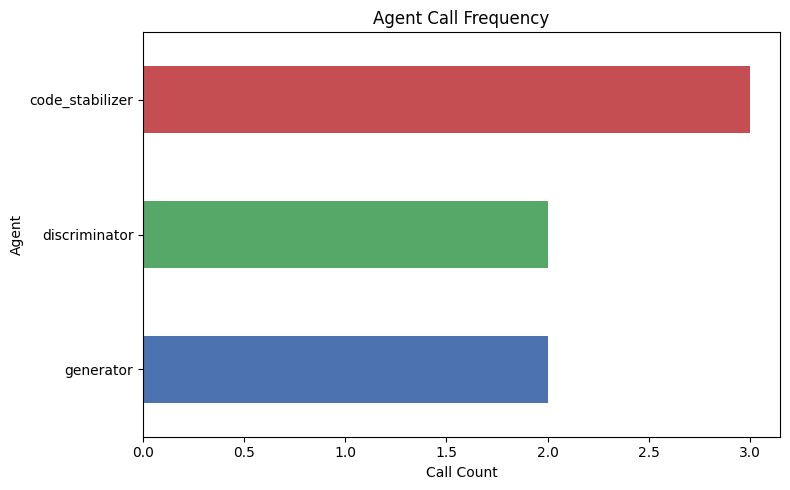

In [2]:
agent_counts_mapped = filtered["agent"].value_counts()
agent_counts_mapped.sort_values().plot(kind="barh", figsize=(8, 5), color=["#4c72b0", "#55a868", "#c44e52"])
plt.title("Agent Call Frequency")
plt.xlabel("Call Count")
plt.ylabel("Agent")
plt.tight_layout()
plt.show()


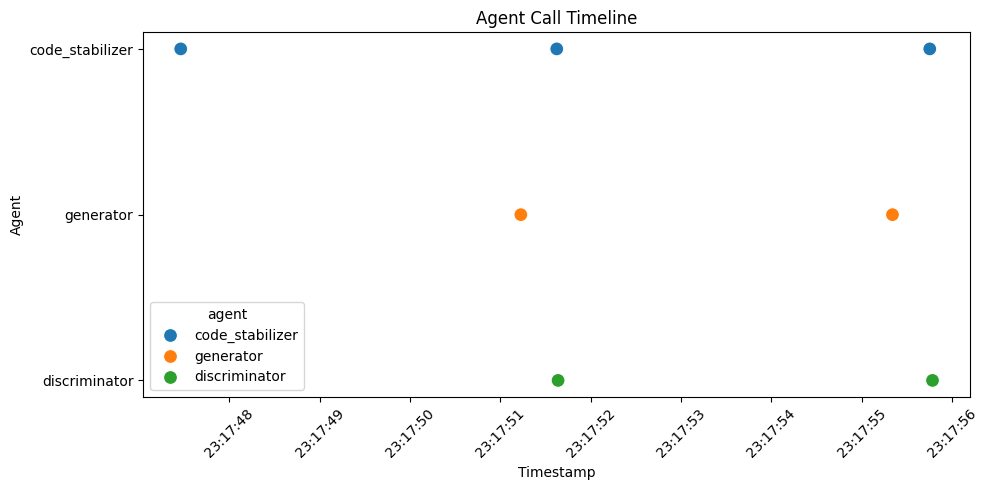

In [3]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=filtered, x="timestamp", y="agent", hue="agent", s=100, palette="tab10")
plt.title("Agent Call Timeline")
plt.xlabel("Timestamp")
plt.ylabel("Agent")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
